In [31]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

### Functions

In [85]:
def preprocess_df(df_raw):
    df = df_raw.copy()
    df['pc'] = df['midi'] % 12
    df = df[df['pc'].notna()]
    df['pc'] = df['pc'].apply(int)
    df['note'] = df['pc'].map(lambda x: pitch_class_names[x])
    
    df['mc_onset_float'] = df['mc_onset'].apply(lambda x: float(Fraction(x)))
    df['order'] = df['mc'] + df['mc_onset_float']

    return df

In [136]:
def generate_pc(df_raw):
    pitchclass = df_raw.copy()
    pitchclass = pitchclass.groupby(by=['order'])[['note', 'pc']].agg(list).reset_index()
    pitchclass['pc'] = pitchclass['pc'].apply(lambda x: list(set(x)))
    return pitchclass

In [138]:
import itertools

def interval_class(lst):
    output = []
    for a, b in itertools.combinations(lst, 2):
        interval = abs(a - b) % 12  # if you're working mod 12
        IC = min(interval, 12 - interval)
        output.append(IC)
    return output

In [153]:
def dissonance(pc):
    harmonies = pc[pc['pc'].apply(lambda x: len(x) > 1)].copy()
    harmonies['interval'] = harmonies['pc'].apply(interval_class)
    harmonies['num notes'] = harmonies['pc'].apply(lambda x: len(x))
    harmonies['dissonance'] = (harmonies['interval'].apply(lambda x: sum(dissonance_table[i] for i in x))) / harmonies['num notes']
    return harmonies

In [142]:
dissonance_table = {
    0: 0.0,    # Unison
    1: 1.0,    # m2/M7
    2: 0.6,    # M2/m7
    3: 0.4,    # m3/M6
    4: 0.2,    # M3/m6
    5: 0.0,    # P4/P5
    6: 0.8,    # Tritone
}

pitch_class_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 
                     'F#', 'G', 'G#', 'A', 'A#', 'B']

In [144]:
path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/metadata.tsv"
metadata = pd.read_csv(path, sep='\t')
metadata

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
0,by_Alexander_Booker,Snarky_Puppy-Shapons_Vindaloo,142,142,"1: 0, 113: -3, 134: 0","1: 9/8, 2: 7/8, 4: 9/8, 5: 7/8, 7: 9/8, 8: 7/8...",8,NaN,Väsen,Shapons Vindaloo,...,NaN,NaN,NaN,NaN,NaN,NaN,"ac-g, e-g, b, nyckelharpa",complete,Concert Key,1
1,by_Alexander_Booker,The_Fearless_Flyers-Ace_of_Aces,57,57,1: 3,1: 4/4,2,NaN,Smith/Dart/Wong/Lettieri/Stratton,Ace Of Aces,...,NaN,NaN,NaN,NaN,NaN,NaN,"g, b, dr",complete,Concert Key,1
2,by_Alexander_Booker,Vulfpeck-Fugue_State,71,71,1: 0,1: 4/4,13,NaN,"Woody Goss, Jack Stratton",Fugue State,...,NaN,NaN,NaN,NaN,NaN,NaN,"ep, g, b, dr",complete,Concert Key,1
3,by_Carles_Margarit,12 Keys Blues - Bob Mintzer,156,156,1: 0,1: 4/4,169,NaN,NaN,12 Keys Blues,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,solo,Bb,1
4,by_Carles_Margarit,26_2 - Coltrane (Concert Key),298,297,1: -1,"1: 4/4, 296: 2/4, 298: 4/4",347,NaN,John Coltrane,26-2,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Concert Key,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,by_seemajorsheetmusic,Superstition - Stevie Wonder,89,89,1: -3,1: 4/4,402,NaN,Comp.: Stevie Wonder,Superstition,...,30-46 (Gb1-Bb2),Bass Guitar (2),51-70 (Eb3-Bb4),NaN,NaN,NaN,"as, ts, tp, tb, g, b, key",complete,"as in Eb, ts, tp in Bb, tb, g, b, key in Conce...",1
289,by_seemajorsheetmusic,The Survivor - Jan Garbarek,27,27,1: 0,1: 4/4,43,NaN,Comp.: Jan Garbarek,The Survivor,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,melody,Bb,1
290,by_seemajorsheetmusic,The Vow - Ole børud,105,105,"1: -1, 49: 6",1: 4/4,160,NaN,Ole Børud,The Vow,...,28-55 (E1-G3),Bass Guitar (2),62-79 (D4-G5),NaN,NaN,NaN,"as, ts, tp, tb, dr, g, b, el-org",complete,"as in Eb, ts, tp in Bb, tb, g, b, org in Conce...",0
291,by_seemajorsheetmusic,The World is Getting Smaller - Snarky Puppy,221,221,1: 1,1: 4/4,392,NaN,Comp.: Michael League\nTranscribed & Arranged ...,The World Is Getting Smaller,...,28-60 (E1-C4),Bass Guitar (2),70-71 (Bb4-B4),Keyboard,NaN,NaN,"ss, ts, tp, tb, b, g, key, dr",complete without solos,"ss, ts, tp in Bb, tb, g, b, key in Concert Key",1


#### Should we separate them into major and minor key compositions??

In [160]:
dfs = []
for row in range(metadata.shape[0]):
    base_path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/notes" 
    path_row = base_path + "/" + metadata.iloc[row,1] + ".tsv"
    try: 
        df = pd.read_csv(path_row, sep='\t')
        df = preprocess_df(df)
        pc = generate_pc(df)
        harmonies = dissonance(pc)
        mean = harmonies['dissonance'].mean()
        dfs.append({
            'artists': metadata.iloc[row]['artists'],
            'workTitle': metadata.iloc[row]['workTitle'],
            'recording_year': metadata.iloc[row]['recording_year'],
            'mean_dissonance': mean
        })
    except Exception as e:
        continue

dfs = pd.DataFrame(dfs)


In [162]:
dfs

,artists,workTitle,recording_year,mean_dissonance
0,Snarky Puppy,Shapons Vindaloo,2015,0.318946
1,The Fearless Flyers,Ace Of Aces,2018,0.356176
2,Vulfpeck,Fugue State,2014,0.438846
3,Bob Mintzer,12 Keys Blues,2010,0.500000
4,John Coltrane,26-2,1964,0.412500
...,...,...,...,...
222,Pat Metheny,Outcasts,1999,0.653362
223,Paul Desmond,All The Things You Are,1962,0.175000
224,Earth Wind and Fire,Can't Hide Love,1975,0.714432
225,Stevie Wonder,I Wish,1976,0.485320


### Plot Average DI over time

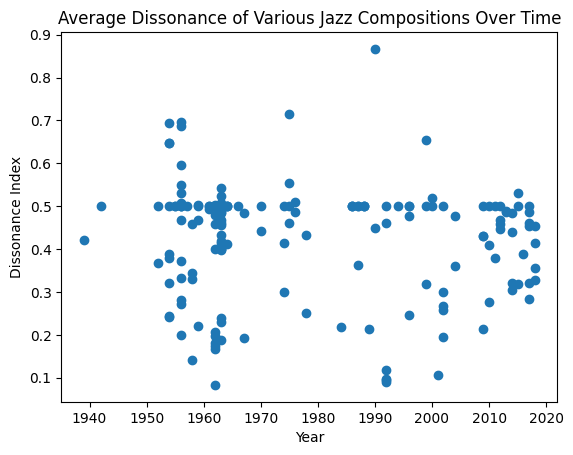

In [178]:
dfs['recording_year'] = pd.to_numeric(dfs['recording_year'], errors='coerce')
dfs = dfs[dfs['recording_year'].notna()].copy()
dfs['recording_year'] = dfs['recording_year'].astype('Int64')
x = dfs['recording_year']
y = dfs['mean_dissonance']
plt.title('Average Dissonance of Various Jazz Compositions Over Time')
plt.xlabel('Year')
plt.ylabel('Dissonance Index')
plt.scatter(x,y)

#### Fit a function to it????